## Step 0 — Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 120)
print("pandas:", pd.__version__)

pandas: 2.3.3


## Step 1 — Upload `ico_coffee_long_with_population.csv`

In [2]:
try:
    from google.colab import files
    print("Running in Colab — select ico_coffee_long_with_population.csv...")
    uploaded = files.upload()
except ImportError:
    print("Not running in Colab — make sure the file is already in the working directory.")

DATA_PATH = Path("ico_coffee_long_with_population.csv")
assert DATA_PATH.exists(), f"{DATA_PATH} not found — upload it in the cell above."


Not running in Colab — make sure the file is already in the working directory.


## Step 2 — Load, fill the Brazil gap, find the top 5

In [3]:
df = pd.read_csv(DATA_PATH)
df['Country'] = df['Country'].replace('Viet Nam', 'Vietnam')

exp_raw = df[df.Metric == "export_kg"].set_index(["Country", "Year"])["value"]
exp_imp = df[df.Metric == "export_kg_imputed"].set_index(["Country", "Year"])["value"]
exp_filled = exp_raw.combine_first(exp_imp).rename("value").reset_index()

avg_export = exp_filled.groupby("Country")["value"].mean().sort_values(ascending=False)
top5 = avg_export.head(5).index.tolist()
print("Top 5 exporters:", top5)

Top 5 exporters: ['Brazil', 'Vietnam', 'Colombia', 'Indonesia', 'India']


## Step 3 — Reshape (million kg)

In [4]:
pivot = exp_filled.pivot_table(index="Year", columns="Country", values="value", aggfunc="first").fillna(0)

others = pivot.drop(columns=top5).sum(axis=1)
stack_df = pivot[top5].copy()
stack_df["Others"] = others
stack_df = stack_df / 1e6  # -> million kg

## Step 4 — Plot, then set alpha per series

`stackplot()` returns a list of `PolyCollection`s in the same column order as `stack_df.columns`. Build an alpha list the same length and same order, then apply it in a loop after the call.

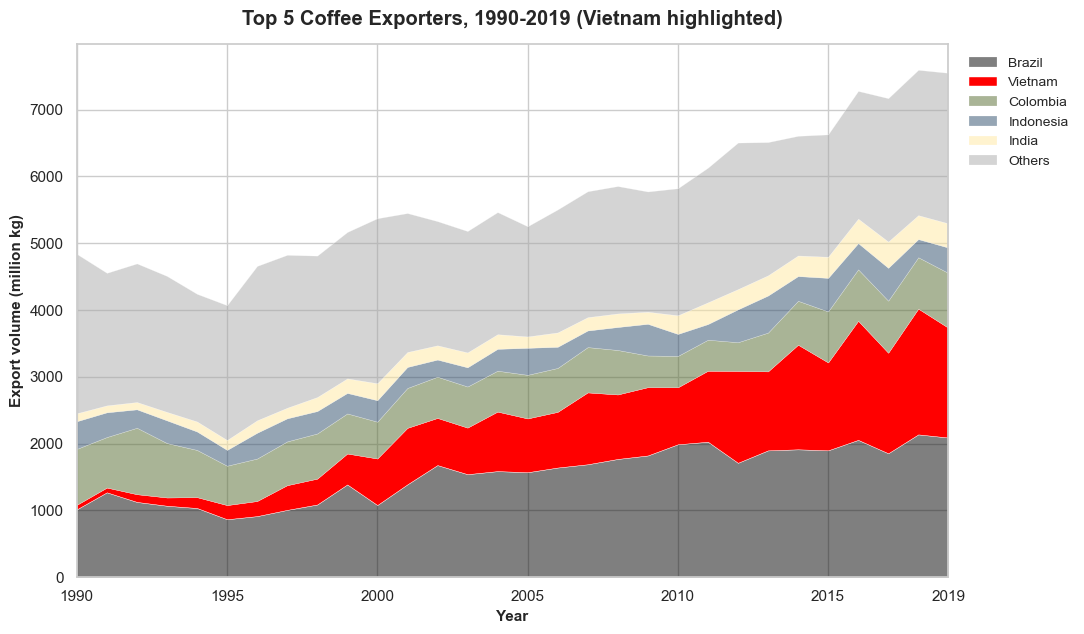

In [5]:
COLORS = ["#000000", "#FF0000", "#556b2f", "#2d4c6b", "#FFe9a1", "#aaaaaa"]
HIGHLIGHT = "Vietnam"
ALPHA_HIGHLIGHT = 1.0
ALPHA_OTHERS = 0.5

fig, ax = plt.subplots(figsize=(11, 6.5))

polys = ax.stackplot(stack_df.index, [stack_df[c] for c in stack_df.columns],
                      labels=stack_df.columns, colors=COLORS,
                      edgecolor="white", linewidth=0.3)

for col_name, poly in zip(stack_df.columns, polys):
    poly.set_alpha(ALPHA_HIGHLIGHT if col_name == HIGHLIGHT else ALPHA_OTHERS)

ax.set_title("Top 5 Coffee Exporters, 1990-2019 (Vietnam highlighted)", fontsize=14.5, fontweight="bold", pad=14)
ax.set_xlabel("Year", fontsize=11,fontweight="bold")
ax.set_ylabel("Export volume (million kg)", fontsize=11,fontweight="bold")
xticks = list(range(1990, 2020, 5)) + [2019]
ax.set_xticks(sorted(set(xticks)))
ax.set_xlim(1990, 2019)
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), frameon=False, fontsize=10)

plt.tight_layout()
plt.savefig("top5_exporters_vietnam_highlight.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

## Step 5 — Download the chart (Colab only)

In [14]:
try:
    from google.colab import files as _colab_files
    _colab_files.download("top5_exporters_vietnam_highlight.png")
except ImportError:
    print(f"Not in Colab — find it locally at: {Path('top5_exporters_vietnam_highlight.png').resolve()}")

Not in Colab — find it locally at: C:\Users\KrissW Laptop\Downloads\graph\Vietnam highlighted top 5\top5_exporters_vietnam_highlight.png
